<p style="font-family:Bookman Old Style;font-size:27px; text-align:center">High-Pass Filtering in the Frequency Domain</p>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">High-Pass Filtering in the Frequency Domain** involves analyzing an image by transforming it into its frequency components using the Fourier Transform. By selectively removing low-frequency components (representing smooth variations like backgrounds) and retaining high-frequency components (edges and fine details), this technique enhances sharp features in the image. Finally, the inverse transform is applied to observe the processed image in the spatial domain.</p></div>

<p style="font-family:Bookman Old Style;font-size:27px">Import libraries</p>

In [71]:
import cv2
import numpy as np
import scipy.fftpack as fp
import matplotlib.pyplot as plt

<p style="font-family:Bookman Old Style;font-size:27px">Load and Convert Image to Grayscale</p> 

In [72]:
img = cv2.imread('../images-videos/lenna.jpg')
img_gry = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
w, h, _ = img.shape

<p style="font-family:Bookman Old Style;font-size:27px">Display original image</p>

(-0.5, 511.5, 511.5, -0.5)

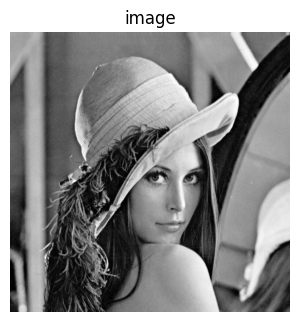

In [73]:
plt.figure(figsize=(8, 8))

plt.subplot(221)
plt.imshow(img_gry, cmap='gray')
plt.title('image')
plt.axis('off')

<p style="font-family:Bookman Old Style;font-size:27px">Perform Fourier Transform</p>

In [74]:
freq = fp.fft2(img_gry)
shift_freq = fp.fftshift(freq)
mag_shift_freq = 20 * np.log1p(np.abs(shift_freq) + 0.01)

<p style="font-family:Bookman Old Style;font-size:27px">Display imag spectrum</p>

(-0.5, 511.5, 511.5, -0.5)

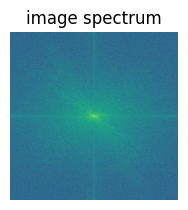

In [75]:
plt.subplot(222)
plt.imshow(mag_shift_freq)
plt.title('image spectrum')
plt.axis('off')

<p style="font-family:Bookman Old Style;font-size:27px">Apply High-Pass Filtering (HPF)</p>

In [76]:
half_w = int(w / 2)
half_h = int(h / 2)
dist = 10
mag_shift_freq[half_w-dist:half_w+(dist+1), half_h-dist:half_h+(dist+1)] = 0  # select low frequencies (20x20)

<p style="font-family:Bookman Old Style;font-size:27px">Display image spectrum after apply HPF</p>

(-0.5, 511.5, 511.5, -0.5)

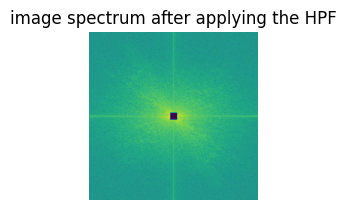

In [77]:
plt.subplot(223)
plt.imshow(mag_shift_freq)
plt.title('image spectrum after applying the HPF')
plt.axis('off')

<p style="font-family:Bookman Old Style;font-size:27px">Inverse Transform to Spatial Domain</p>

In [78]:
shift_freq[half_w-dist:half_w+(dist+1), half_h-dist:half_h+(dist+1)] = 0
new_img = np.clip(fp.ifft2(fp.ifftshift(shift_freq)).real, 0, 255)

<p style="font-family:Bookman Old Style;font-size:27px">Display final result</p>

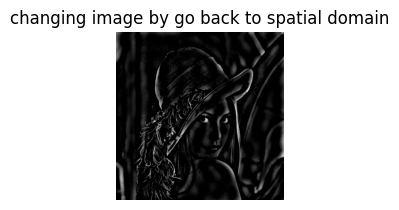

In [79]:
plt.subplot(224)
plt.imshow(new_img, cmap='gray')
plt.title('changing image by go back to spatial domain')
plt.axis('off')

plt.show()

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">The code block below demonstrates the application of the high-pass filter (HPF) using various frequency cut-off values, F.
</p></div>

<p style="font-family:Bookman Old Style;font-size:27px">Load and Preprocess the Image</p>

In [80]:
img1 = cv2.imread('../images-videos/lenna.jpg')
img_gry1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
w, h = img_gry1.shape

half_w = int(w / 2)
half_h = int(h / 2)

<p style="font-family:Bookman Old Style;font-size:27px">Compute the 2D Fourier Transform</p>

In [81]:
freq1 = fp.fft2(img_gry1)

<p style="font-family:Bookman Old Style;font-size:27px">Define SNR Calculation Function</p>

In [82]:
def calc_snr(image):
    signal = np.mean(image)  # mean of the signal
    noise = np.std(image)
    if noise != 0:
        return signal / noise
    else:
        return 0

<p style="font-family:Bookman Old Style;font-size:27px">Apply High-Pass Filter and Visualize Results</p>

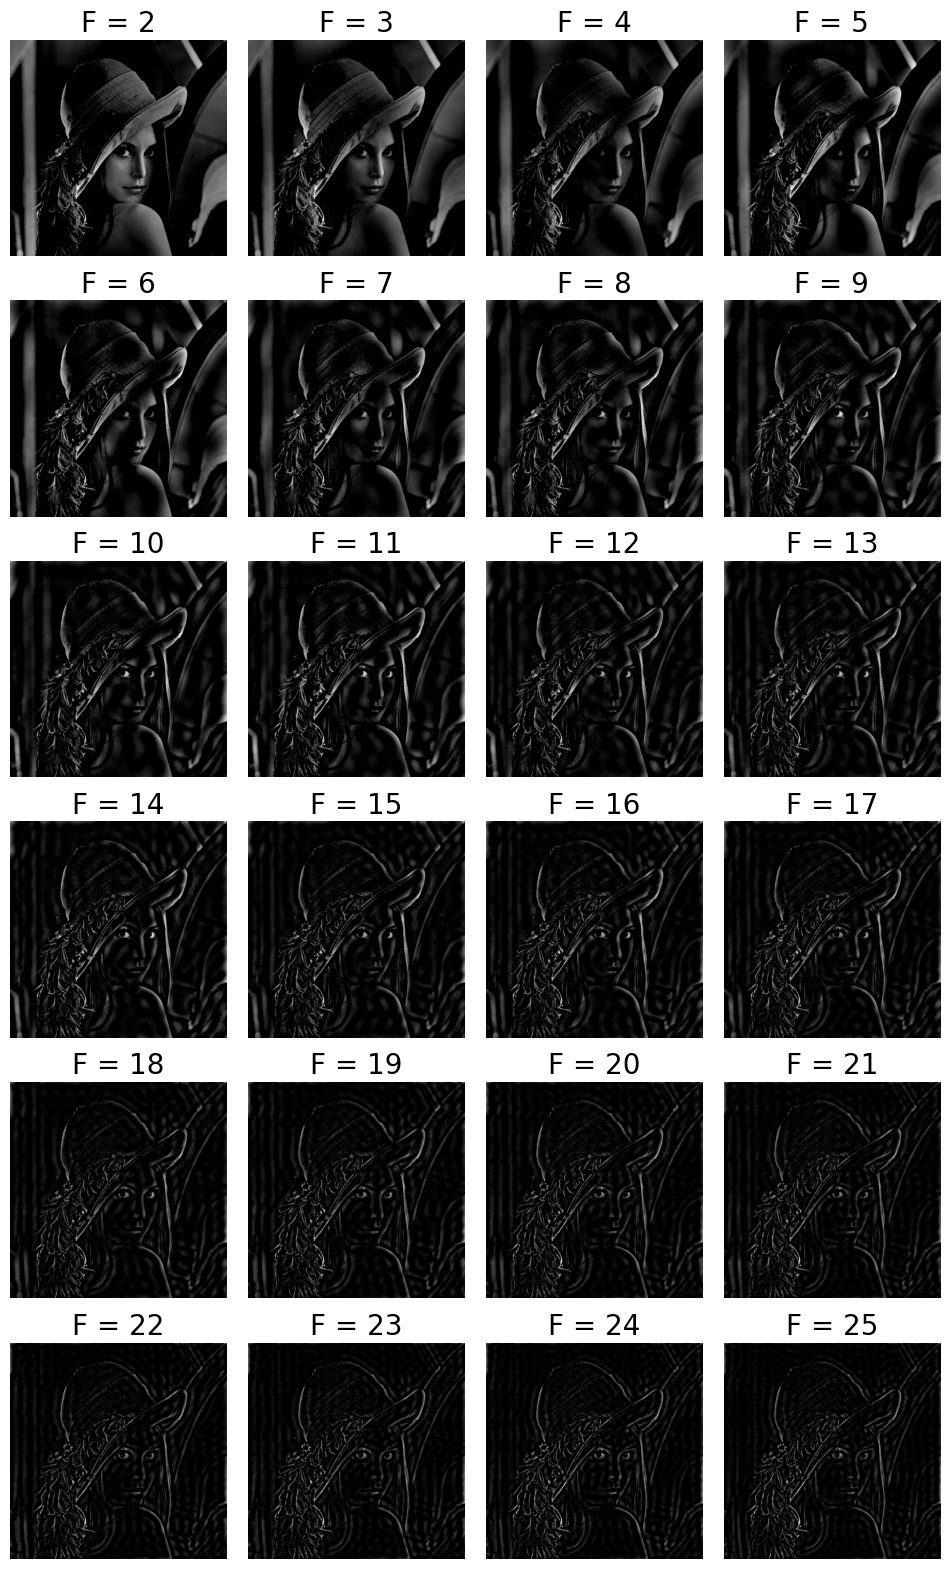

In [83]:
lists = list(range(1, 25))
snrs = []
plt.figure(figsize=(12, 20))

for l in lists:
    freq2 = np.copy(freq1)
    shift_freq = fp.fftshift(freq2)
    shift_freq[half_w - l:half_w + (l + 1), half_h - l:half_h + (l + 1)] = 0
    new_img = np.clip(fp.ifft2(fp.ifftshift(shift_freq)).real, 0, 255)
    snrs.append(calc_snr(new_img))
    plt.subplot(6, 4, l)
    plt.imshow(new_img, cmap='gray')
    plt.title('F = ' + str(l + 1), size=20)
    plt.axis('off')
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

<p style="font-family:Bookman Old Style;font-size:27px">Plot SNR vs. Cut-Off Frequency</p>

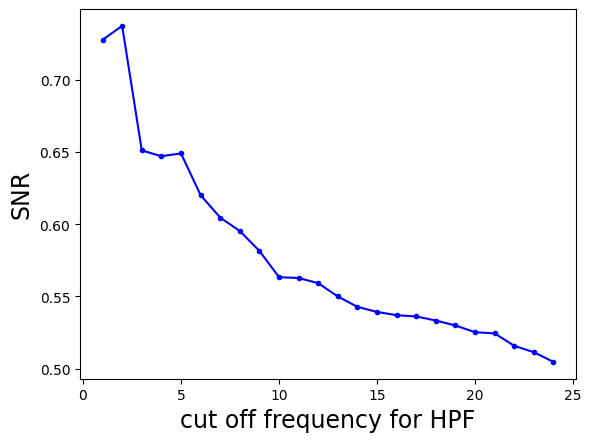

In [84]:
plt.plot(lists, snrs, 'b.-')
plt.xlabel('cut off frequency for HPF', size=17)
plt.ylabel('SNR', size=17)
plt.show()